In [ ]:
import pandas as pd

seed = 23

data = pd.read_pickle('./f1_23_monaco.pkl')

In [245]:
sample_data = data.dtypes.to_frame().reset_index()
sample_data.columns=['name','dtype']
sample_data[:]

,name,dtype
0,Time,timedelta64[ns]
1,Driver,object
2,DriverNumber,int64
3,LapTime,float64
4,LapNumber,int64
5,Stint,int64
6,PitOutTime,timedelta64[ns]
7,PitInTime,timedelta64[ns]
8,Sector1Time,timedelta64[ns]
9,Sector2Time,timedelta64[ns]


In [246]:
# data.info()
# data.columns
# data.dtypes
# len(data.columns)
# data.describe()
# data.info()
# data.head(10)[["Driver"]]
# data.isnull().any()
# data['Driver']
data.iloc[1000,:].to_frame().T


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,IsAccurate
1000,0 days 02:28:54.204000,OCO,31,101.123,63,3,NaT,NaT,0 days 00:00:27.172000,0 days 00:00:47.560000,...,9,True,Alpine,0 days 02:27:13.081000,2023-05-28 14:28:14.058000,1,3,False,NaN,True


In [247]:
data.loc[1000, 'Driver']

'OCO'

In [248]:
data['Sector1Time'].count()

np.int64(1259)

In [249]:
data['Team'].unique()
data['Team'].nunique()
len(data['Team'].unique())

10

In [250]:
data['Team'].value_counts().to_frame().reset_index()

,Team,count
0,McLaren,132
1,Mercedes,132
2,AlphaTauri,130
3,Ferrari,130
4,Alpine,129
5,Alfa Romeo,126
6,Red Bull Racing,124
7,Haas F1 Team,122
8,Williams,121
9,Aston Martin,113


In [251]:
data.sort_values('LapTime')[['Driver']]

,Driver
561,HAM
815,LEC
873,GAS
893,GAS
892,LEC
...,...
1123,MAG
961,DEV
967,ALB
968,PER


In [269]:
time_frame['LapStartTime'] = pd.to_timedelta(data['LapStartTime'])
data['LapStartTime']

0      0 days 01:03:27.458000
1      0 days 01:03:28.747000
2      0 days 01:03:29.859000
3      0 days 01:03:30.610000
4      0 days 01:03:31.805000
                ...          
1254   0 days 02:50:30.984000
1255   0 days 02:50:32.308000
1256   0 days 02:50:40.437000
1257   0 days 02:50:39.107000
1258   0 days 02:50:46.594000
Name: LapStartTime, Length: 1259, dtype: timedelta64[ns]

Text(0, 0.5, 'DriversSS')

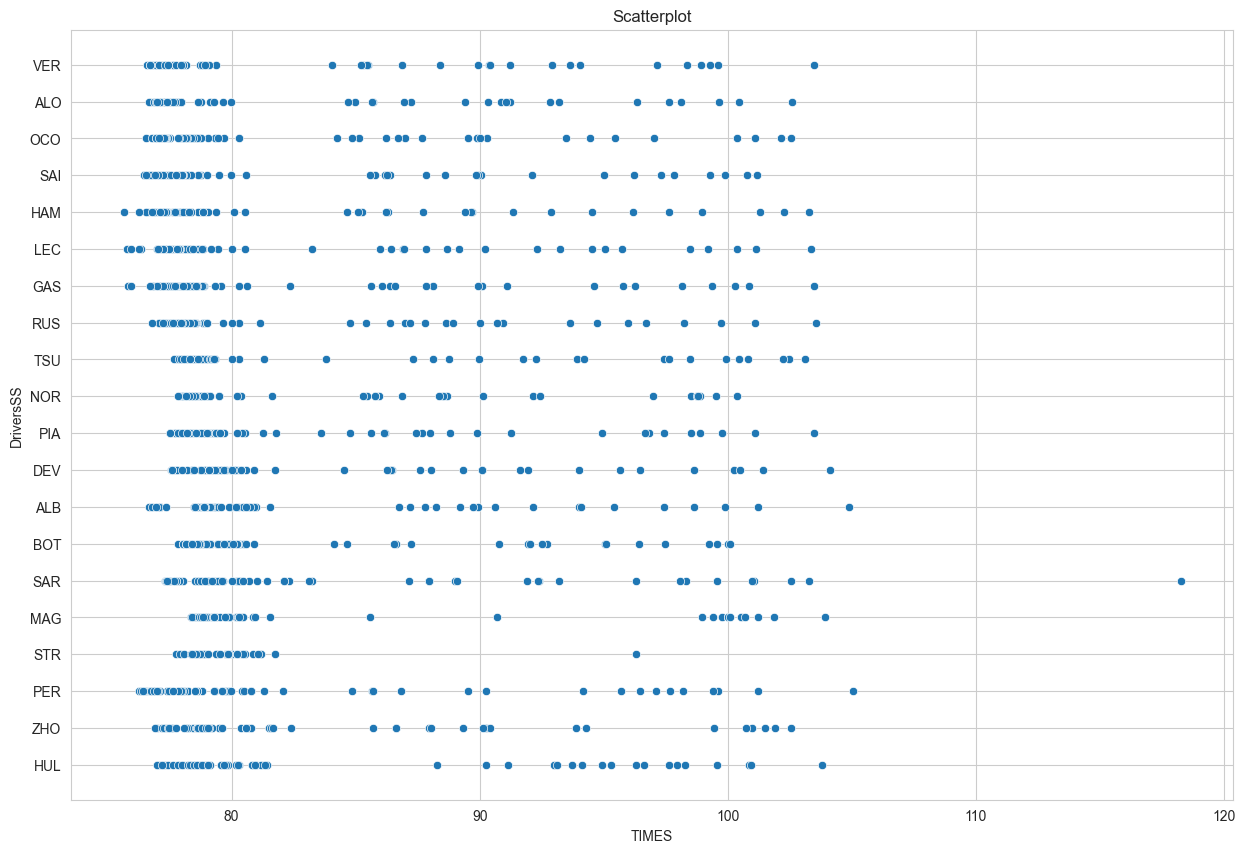

In [286]:
import seaborn as sns
import matplotlib.pyplot as plt

figsize = (15, 10)

plt.figure(figsize=figsize)

hist = sns.scatterplot(data, y = 'Driver', x = data['LapTime'])

hist.set_title('Scatterplot')
hist.set_xlabel('TIMES')
hist.set_ylabel('DriversSS')


Text(0.5, 1.0, 'Correlation Heatmap')

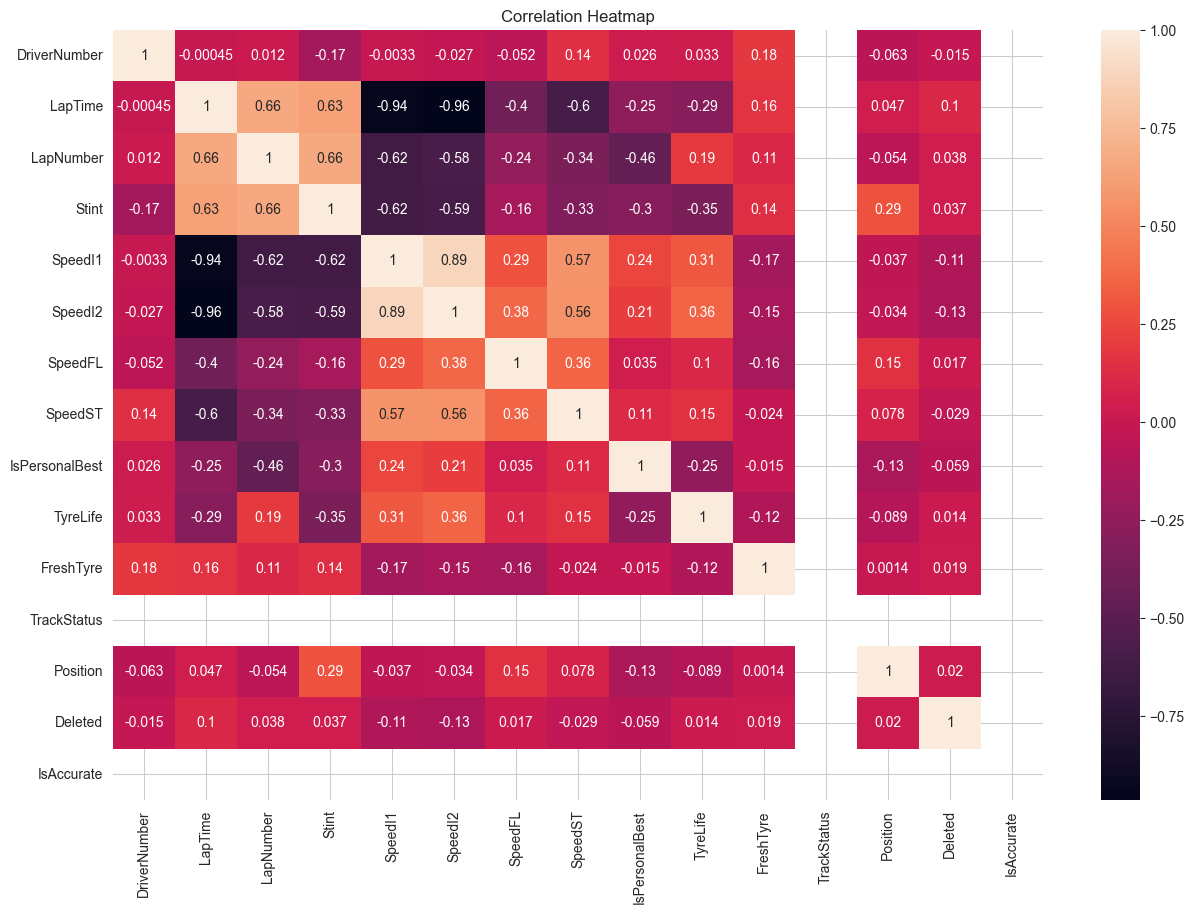

In [289]:
plt.figure(figsize=figsize)

sns.heatmap(data=data.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')